# Clustering Models
__Reading__
* Geron, Chapter 9

__Additional Resources__
* https://www.analyticsvidhya.com/blog/2020/10/quick-guide-to-evaluation-metrics-for-supervised-and-unsupervised-machine-learning/#:~:text=The%20two%20most%20popular%20evaluation,which%20you%20will%20explore%20next.&text=The%20Silhouette%20Coefficient%20is%20defined,points%20in%20the%20same%20cluster.
* https://stats.stackexchange.com/questions/21807/evaluation-measures-of-goodness-or-validity-of-clustering-without-having-truth
* [YouTube: DataScience A-Z for Beginners and Advance: Part 41 How to Choose the Number of Clusters](https://www.youtube.com/watch?v=FqIGui0rwh4)

## Evaluation of Cluster Models
The performance of a cluster model can't be evaluated as Supervised models, which compare the model's results with pre-labeled data. However, clustering models are unsupervised, so generally have no pre-labeled to compare.

The secret will be to look at qualities of the clusters formed by the model. For example, how big are the clusters? How does the distribution of one cluster compare to other clusters? Here, we will look at external indices and internal indices.
* An __external index__ looks at the distribution and boundaries of one cluster to those of other clusters. This means we generally base the evaluation on a known cluster structure (labels).
* An __internal index__ looks at the individual cluster without any external information. This is not dependent on any pre-known structure.

A few possible evaluations:
* Within-Cluster Sum of Squares (WCSS) and the Elbow Method (See [WCSS code example](./Code/20_ClusteringModels.ipynb))
* Silhouette index
* Dunn index
* R-squared index
* Davies-Bouldin index
* Hartigan index
* Root-mean-square standard deviation (RMSSTD)

Goals:
1. Minimize distance between points in a cluster
2. Maximize distance between clusters

## WCSS and the Elbow Method
In Scikit-Learn, the KMeans algorithm uses a metric called __inertia__, which is also known as "Within-Cluster Sum of Squares" or WCSS. 
* Measure the squared distance from each point to the nearest centroid
* Take the sum of these squared distances

$$WCSS = \sum_{i=1}^k \sum_{x\in C_i} ||x-\mu_i||^2$$

The WCSS is the metric of the total squared distance from points to their centroids. We want to minimize these distances. Of course, the more centroids we have, the lower these distances will be. But that isn't always better. At some point, adding more centroids is meaningless.

This is where the __Elbow Method__ is useful.

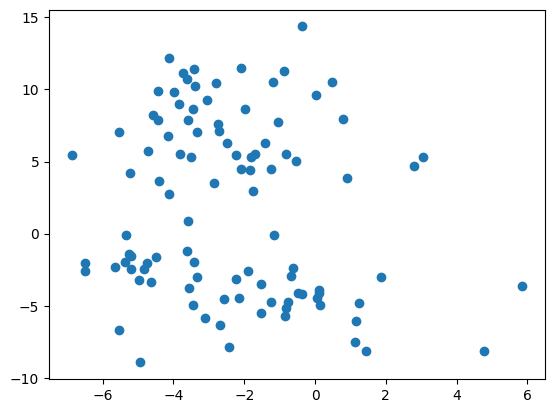

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=100, n_features=2, centers=4,
                  cluster_std=1.8,random_state=50)

plt.scatter(X[:,0], X[:,1])

## WCSS and the Elbow Method

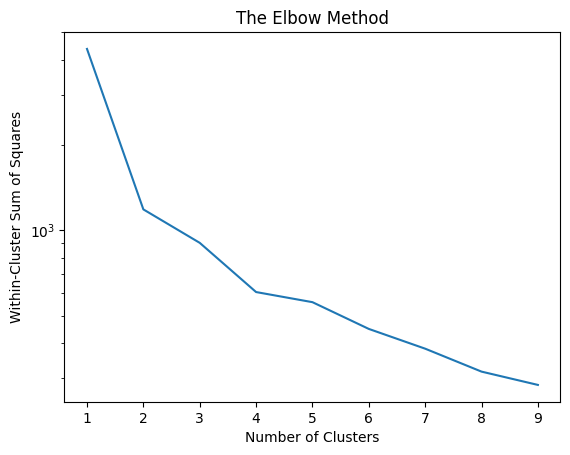

In [2]:
from sklearn.cluster import KMeans

num_clusters = []
wcss = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    num_clusters.append(k)
    wcss.append(kmeans.inertia_)

plt.plot(num_clusters,wcss)
plt.yscale('log') # sets y-axis to a logarithmic scale to emphasize change in slope
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares')
plt.show()

## Evaluate without labels

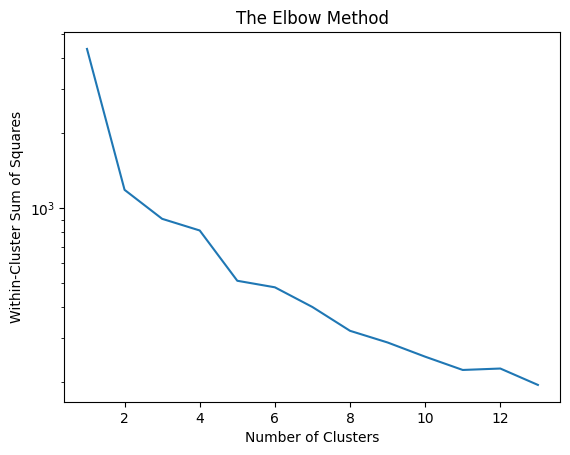

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs(n_samples=100, n_features=2, centers=4,
                  cluster_std=1.8,random_state=50)


# Evaluate using WCSS and Elbow Method
num_clusters = []
wcss = []

for k in range(1, 14):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    num_clusters.append(k)
    wcss.append(kmeans.inertia_)

plt.plot(num_clusters,wcss)
plt.yscale('log')
plt.title('The Elbow Method') # sets y-axis to a logarithmic scale to emphasize change in slope
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares')
plt.show()

#### Number-guessing game

In [4]:
rnd_num = np.random.randint(2,10)

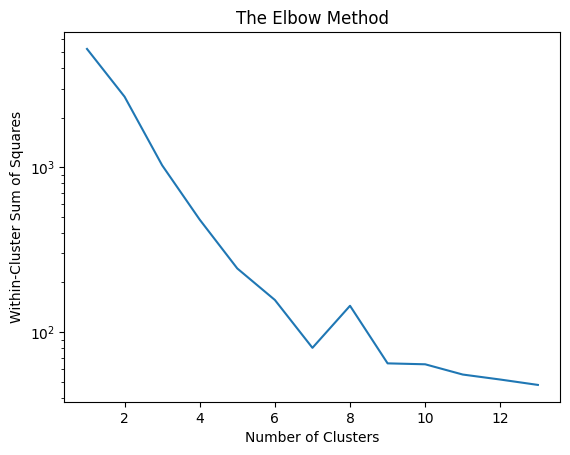

In [5]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=100, n_features=2, centers=rnd_num,
                  cluster_std=0.7, random_state=99)

num_clusters = []
wcss = []

for k in range(1,14):
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(X)
  num_clusters.append(k)
  wcss.append(kmeans.inertia_)

plt.plot(num_clusters, wcss)
plt.yscale('log')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares')
plt.show()

In [6]:
print(rnd_num)

7


## Silhouette Index

Another 

$$s = \frac{b-a}{\max(a,b)}$$

where
* $a$ is the mean distance to the other instances in the same cluster (i.e., the mean intra-cluster distance)
* $b$ is the mean nearest-cluster distance (i.e., the mean distance to the instances of the next closest cluster, defined as the one that minimizes $b$, excluding the instance's own cluster)

A silhouette score will be between +1 and -1.
* $s\approx +1$ means the instance is well inside its own cluster
* $s\approx 0$ means the instance is close to the cluster boundary
* $s\approx -1$ means the instance is likely assigned to the wrong cluster

<img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781098125967/files/assets/mls3_0910.png" width=450 alt="Silhouette diagram example">

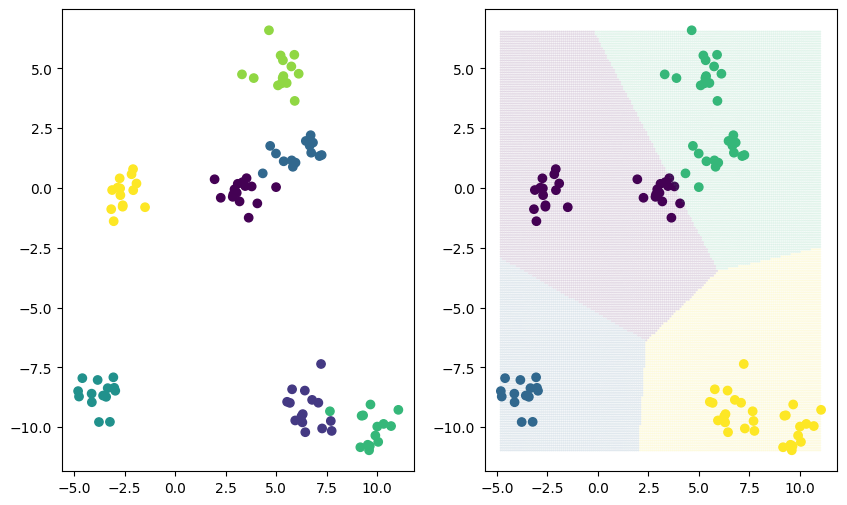

In [7]:
from sklearn.cluster import KMeans

k=4
kmeans = KMeans(n_clusters=k, random_state=30, n_init='auto')
kmeans.fit(X)

relabel = np.choose(kmeans.labels_,[0,3,1,2])
#y_pred = np.choose(y_test)

# Results Map
grid_x, grid_y = np.meshgrid(np.arange(X[:,0].min(), X[:,0].max(), 0.1), np.arange(X[:,1].min(), X[:,1].max(), 0.1))
grid_pts = np.array([grid_x.flatten(),grid_y.flatten()]).T
grid_grp = kmeans.predict(grid_pts)
grid_grp = np.choose(grid_grp, [0,3,1,2])

fig,ax = plt.subplots(1,2, figsize=(10,6))
ax[0].scatter(X[:,0], X[:,1], c=y)
ax[1].scatter(X[:,0], X[:,1], c=relabel)
ax[1].scatter(grid_pts[:,0], grid_pts[:,1], c=grid_grp, alpha=0.1, marker='.', s=2)

In [8]:
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
silhouette_score(X, kmeans.labels_)

0.7164670143250328

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Silhouette Diagram'}, xlabel='Silhouette Coefficient', ylabel='Cluster'>,
 0.7164670143250328)

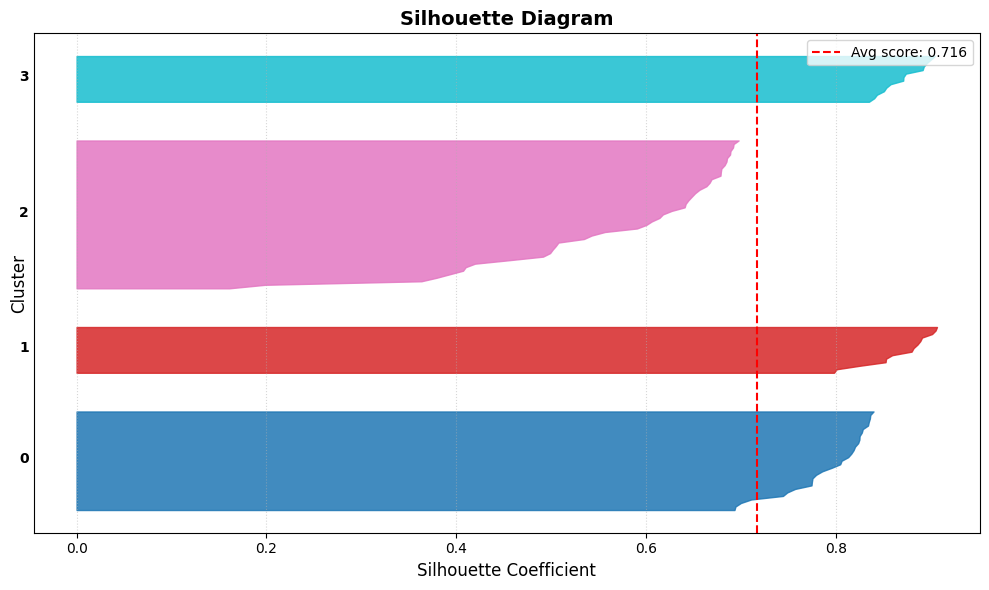

In [9]:
# See the clusterfunctions.py file in the Code folder for
#     details of the plot_silhouette function

from Code.clusterfunctions import plot_silhouette
plot_silhouette(X, kmeans.labels_)

## Hard Clustering vs. Soft Clustering

When determining which cluster a point should belong to, should it be fully clustered into one group, or could a point be partially clustered into one group and partially into another?
* Hard clustering: a point is assigned 100% into one group
  * KMeans is typically a Hard Clustering technique
* Soft clustering: a point is assigned partially into multiple different groups
  * Gaussian Mixture Models is a good example of a model that can be hard or soft